# Statistics Assignment: Hypothesis Testing and Confidence Intervals

This notebook contains two independent statistics assignments:

1. **Hypothesis Testing** — Investigating Bombay Hospitality Ltd.'s restaurant owners' claim that weekly operating costs are higher than a theoretical cost model predicts.
2. **Confidence Intervals** — Estimating the mean durability of print-heads from a small destructive-testing sample, using both the t-distribution and the z-distribution.

In [1]:
# Import required libraries
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100

---
# Part 1: Hypothesis Testing — Restaurant Weekly Operating Costs

**Background:** Bombay Hospitality Ltd. operates a franchise model for producing exotic Norwegian dinners throughout New England. The theoretical weekly operating cost model is:

$$W = \$1000 + \$5X$$

where $X$ is the number of units produced in a week. Restaurant owners report that their actual observed weekly costs are higher than this model predicts.

**Data provided:**
- Sample of **n = 25** restaurants, sample mean weekly cost $\bar{x}$ = **Rs. 3,050**
- Units produced per week, $X$, follows a Normal distribution with mean $\mu_X$ = 600 units and standard deviation $\sigma_X$ = 25 units

**Objective:** use hypothesis testing to check whether there is statistical evidence for the owners' claim that weekly costs are higher than the model predicts.

In [2]:
# Given data
x_bar = 3050        # sample mean weekly cost (Rs.)
n = 25               # sample size
mu_X = 600           # mean units produced per week
sigma_X = 25         # standard deviation of units produced per week

print(f"Sample mean weekly cost (x_bar): Rs. {x_bar}")
print(f"Sample size (n): {n}")
print(f"Mean units produced (mu_X): {mu_X}")
print(f"Std dev of units produced (sigma_X): {sigma_X}")

Sample mean weekly cost (x_bar): Rs. 3050
Sample size (n): 25
Mean units produced (mu_X): 600
Std dev of units produced (sigma_X): 25


## Step 1: State the Hypotheses

The cost model is $W = 1000 + 5X$. Under this model, the *theoretical* mean weekly cost is $\mu_W = 1000 + 5 \times \mu_X$.

The restaurant owners' claim is that actual costs are **higher** than this theoretical value — a directional (one-tailed, right-tailed) claim. So we test:

- **Null hypothesis (H₀):** $\mu = 1000 + 5(600) = 4000$ — the average weekly operating cost matches the theoretical model (no increase).
- **Alternative hypothesis (H₁):** $\mu > 4000$ — the average weekly operating cost is **higher** than the theoretical model predicts (the owners' claim).

This is a **right-tailed** z-test, since the population standard deviation of $W$ is known (derived from the known standard deviation of $X$) and the sample size is reasonably large.

In [3]:
# Theoretical mean weekly cost under the cost model, W = 1000 + 5X
mu = 1000 + 5 * mu_X
print(f"H0: mu = {mu}   (theoretical mean weekly cost under the model)")
print(f"H1: mu > {mu}   (owners' claim: actual cost is higher)")

H0: mu = 4000   (theoretical mean weekly cost under the model)
H1: mu > 4000   (owners' claim: actual cost is higher)


## Step 2: Calculate the Test Statistic

Since $W = 1000 + 5X$ is a linear transformation of $X$, its standard deviation scales by the same factor of 5:

$$\sigma_W = 5 \times \sigma_X$$

The test statistic is:

$$z = \frac{\bar{x} - \mu}{\sigma_W / \sqrt{n}}$$

In [4]:
# Standard deviation of weekly cost W (since W = 1000 + 5X, sd scales by the same factor of 5)
sigma_W = 5 * sigma_X
print(f"sigma_W = 5 * {sigma_X} = {sigma_W}")

# Standard error of the sample mean
standard_error = sigma_W / np.sqrt(n)
print(f"Standard error = sigma_W / sqrt(n) = {sigma_W} / sqrt({n}) = {standard_error:.4f}")

# Test statistic
z_stat = (x_bar - mu) / standard_error
print(f"\nTest statistic z = (x_bar - mu) / standard error")
print(f"                  = ({x_bar} - {mu}) / {standard_error:.4f}")
print(f"                  = {z_stat:.4f}")

sigma_W = 5 * 25 = 125
Standard error = sigma_W / sqrt(n) = 125 / sqrt(25) = 25.0000

Test statistic z = (x_bar - mu) / standard error
                  = (3050 - 4000) / 25.0000
                  = -38.0000


## Step 3: Determine the Probability (p-value) and Critical Value

Using significance level $\alpha = 0.05$ for a right-tailed test:
- **Critical value:** the z-value beyond which we'd reject H₀, i.e. $z_{0.05}$ such that $P(Z > z_{0.05}) = 0.05$.
- **p-value:** $P(Z > z_{\text{calculated}})$ — the probability of observing a test statistic at least this extreme, if H₀ were true.

In [5]:
alpha = 0.05

# Critical value for a right-tailed test at alpha = 0.05
z_critical = stats.norm.ppf(1 - alpha)
print(f"Critical value (z_critical) at alpha={alpha}: {z_critical:.4f}")

# p-value: P(Z > z_stat) for a right-tailed test
p_value = stats.norm.sf(z_stat)
print(f"p-value = P(Z > {z_stat:.4f}) = {p_value:.6f}")

Critical value (z_critical) at alpha=0.05: 1.6449
p-value = P(Z > -38.0000) = 1.000000


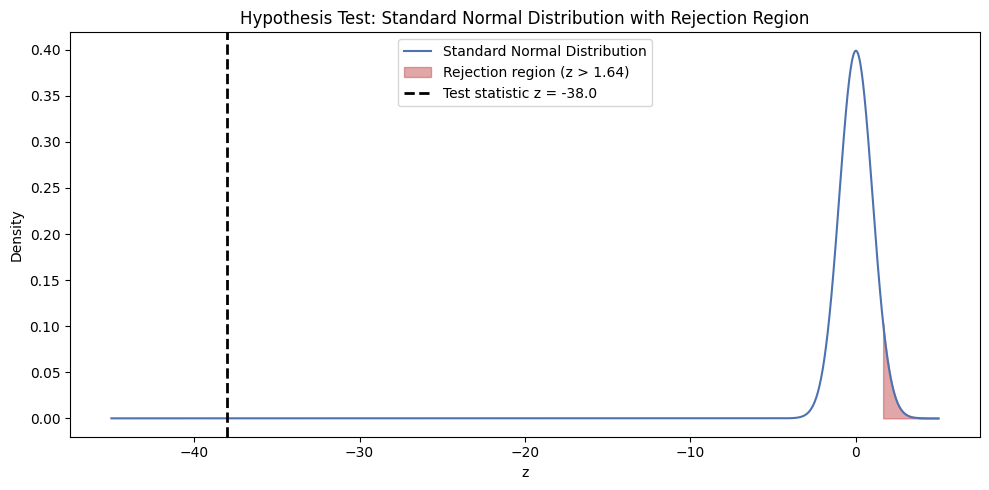

In [6]:
# Visualize the standard normal distribution, the critical region, and where our test statistic falls
fig, ax = plt.subplots(figsize=(10, 5))
x_range = np.linspace(-45, 5, 2000)
ax.plot(x_range, stats.norm.pdf(x_range), color="#4C72B0", label="Standard Normal Distribution")

# Shade the rejection region (right tail beyond z_critical)
x_reject = np.linspace(z_critical, 5, 200)
ax.fill_between(x_reject, stats.norm.pdf(x_reject), color="#C44E52", alpha=0.5,
                 label=f"Rejection region (z > {z_critical:.2f})")

ax.axvline(z_stat, color="black", linestyle="--", linewidth=2,
           label=f"Test statistic z = {z_stat:.1f}")
ax.set_title("Hypothesis Test: Standard Normal Distribution with Rejection Region")
ax.set_xlabel("z")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

**Reading the plot:** the test statistic ($z = -38$) falls extremely far into the *left* tail of the distribution — nowhere near the right-tail rejection region we defined for testing an *increase* in costs. This already strongly hints at the conclusion below.

## Step 4: Make a Decision

Compare the test statistic to the critical value (or equivalently, compare the p-value to $\alpha$):

In [7]:
print(f"Test statistic z         = {z_stat:.4f}")
print(f"Critical value z_critical = {z_critical:.4f}")
print(f"p-value                   = {p_value:.6f}")
print(f"alpha                     = {alpha}")
print()

reject_by_stat = z_stat > z_critical
reject_by_pvalue = p_value < alpha

print(f"Decision rule (test statistic): reject H0 if z_stat > z_critical  ->  {z_stat:.2f} > {z_critical:.2f}? {reject_by_stat}")
print(f"Decision rule (p-value):        reject H0 if p_value < alpha      ->  {p_value:.4f} < {alpha}? {reject_by_pvalue}")

if reject_by_stat:
    print("\nDecision: REJECT the null hypothesis H0.")
else:
    print("\nDecision: FAIL TO REJECT the null hypothesis H0.")

Test statistic z         = -38.0000
Critical value z_critical = 1.6449
p-value                   = 1.000000
alpha                     = 0.05

Decision rule (test statistic): reject H0 if z_stat > z_critical  ->  -38.00 > 1.64? False
Decision rule (p-value):        reject H0 if p_value < alpha      ->  1.0000 < 0.05? False

Decision: FAIL TO REJECT the null hypothesis H0.


## Step 5: Conclusion

**We fail to reject the null hypothesis.** The test statistic ($z = -38$) is nowhere near the critical value ($z = 1.645$) needed to conclude that costs are higher — in fact it lies at the extreme opposite (left) end of the distribution, and the p-value ($\approx 1.0$) is far greater than $\alpha = 0.05$.

**There is no statistical evidence to support the restaurant owners' claim that weekly operating costs are higher than the theoretical model suggests.**

Interestingly, the sample mean (Rs. 3,050) is actually **substantially lower** than the theoretical model's prediction (Rs. 4,000), which is the opposite of what the owners claimed. Since our hypothesis test was specifically set up to detect an *increase* (a one-tailed test in the upper direction), we cannot use this test to formally conclude that costs are lower — that would require a separate left-tailed test. But it's clear from this analysis that the data does not support a claim of increased costs, and owners may want to re-examine their assumptions or data collection before pursuing this claim further.

---
# Part 2: Confidence Intervals — Print-Head Durability

**Background:** In quality control, destructive sampling is sometimes the only way to test a product, which forces the use of small sample sizes due to cost. A manufacturer wants to estimate the mean durability of their print-heads (in millions of characters printed before failure), based on a small destructive sample.

**Data:** durability (in millions of characters) of 15 randomly selected print-heads:

In [8]:
# The sample data
durability = np.array([1.13, 1.55, 1.43, 0.92, 1.25, 1.36, 1.32,
                        0.85, 1.07, 1.48, 1.20, 1.33, 1.18, 1.22, 1.29])
n = len(durability)

print(f"Sample size: {n}")
print(f"Data: {durability}")

Sample size: 15
Data: [1.13 1.55 1.43 0.92 1.25 1.36 1.32 0.85 1.07 1.48 1.2  1.33 1.18 1.22
 1.29]


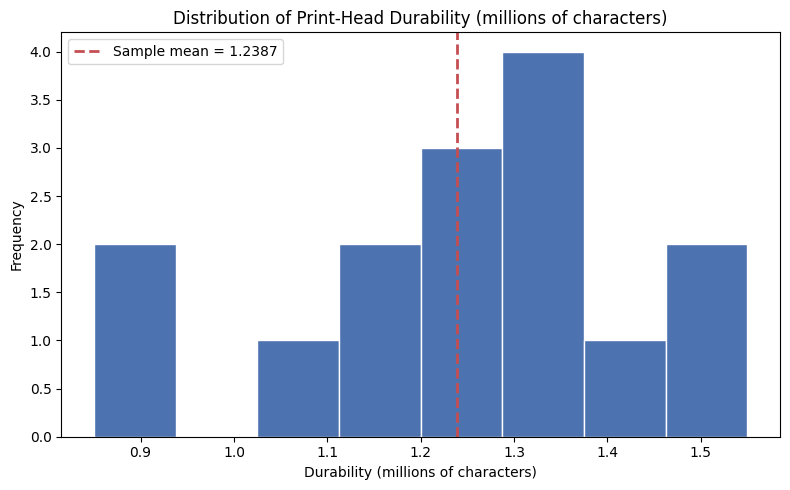

In [9]:
# Visualize the sample distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(durability, bins=8, color="#4C72B0", edgecolor="white")
ax.axvline(durability.mean(), color="#C44E52", linestyle="--", linewidth=2,
           label=f"Sample mean = {durability.mean():.4f}")
ax.set_title("Distribution of Print-Head Durability (millions of characters)")
ax.set_xlabel("Durability (millions of characters)")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

## Part (a): 99% Confidence Interval Using the Sample Standard Deviation

**Why the t-distribution?** With only $n = 15$ observations, the sample size is small, and — critically — we do **not** know the true population standard deviation; we only have the *sample* standard deviation as an estimate of it. Using the sample standard deviation as a stand-in for the unknown population standard deviation adds extra uncertainty, especially with a small sample. The **t-distribution** accounts for this by having heavier tails than the normal distribution (and correspondingly larger critical values), which correctly widens the confidence interval to reflect that extra uncertainty. As $n$ grows large, the t-distribution converges to the normal distribution — but with $n=15$, the difference is still meaningful.

**Steps:**
1. Compute the sample mean $\bar{x}$ and sample standard deviation $s$ (using $n-1$ in the denominator — Bessel's correction — since $s$ is estimated from the same data used to compute $\bar{x}$).
2. Find the critical t-value for a 99% confidence level with $n-1$ degrees of freedom.
3. Compute the margin of error: $t_{crit} \times \dfrac{s}{\sqrt{n}}$.
4. Construct the interval: $\bar{x} \pm \text{margin of error}$.

In [10]:
# Step 1: sample mean and sample standard deviation
sample_mean = durability.mean()
sample_std = durability.std(ddof=1)   # ddof=1 for the SAMPLE standard deviation (Bessel's correction)

print(f"Sample mean (x_bar): {sample_mean:.4f} million characters")
print(f"Sample standard deviation (s): {sample_std:.4f} million characters")

Sample mean (x_bar): 1.2387 million characters
Sample standard deviation (s): 0.1932 million characters


In [11]:
# Step 2: critical t-value for 99% confidence, df = n - 1
confidence_level = 0.99
alpha_ci = 1 - confidence_level
df = n - 1

# Two-tailed interval, so we split alpha across both tails: use the (1 - alpha/2) quantile
t_critical = stats.t.ppf(1 - alpha_ci / 2, df)
print(f"Degrees of freedom: {df}")
print(f"Critical t-value (99% confidence, df={df}): {t_critical:.4f}")

Degrees of freedom: 14
Critical t-value (99% confidence, df=14): 2.9768


In [12]:
# Step 3: margin of error
margin_of_error_t = t_critical * (sample_std / np.sqrt(n))
print(f"Margin of error = t_critical * (s / sqrt(n))")
print(f"                = {t_critical:.4f} * ({sample_std:.4f} / sqrt({n}))")
print(f"                = {margin_of_error_t:.4f}")

# Step 4: confidence interval
ci_lower_t = sample_mean - margin_of_error_t
ci_upper_t = sample_mean + margin_of_error_t

print(f"\n99% Confidence Interval (using sample std dev, t-distribution):")
print(f"  ({ci_lower_t:.4f}, {ci_upper_t:.4f}) million characters")

Margin of error = t_critical * (s / sqrt(n))
                = 2.9768 * (0.1932 / sqrt(15))
                = 0.1485

99% Confidence Interval (using sample std dev, t-distribution):
  (1.0902, 1.3871) million characters


**Interpretation:** we are 99% confident that the true population mean durability of these print-heads lies between approximately **1.090 and 1.387 million characters**. (More precisely: if we repeated this sampling process many times and built a 99% CI each time, about 99% of those intervals would contain the true population mean.)

## Part (b): 99% Confidence Interval Using a Known Population Standard Deviation

Now suppose the population standard deviation is **known** to be $\sigma = 0.2$ million characters (rather than estimated from the sample). Since $\sigma$ is now a known, fixed population parameter rather than an estimate, we no longer need the extra uncertainty-adjustment the t-distribution provides — the **z-distribution (standard normal)** is the correct choice here.

**Steps:**
1. Use the same sample mean $\bar{x}$ as before (still our best point estimate of the population mean).
2. Find the critical z-value for a 99% confidence level.
3. Compute the margin of error: $z_{crit} \times \dfrac{\sigma}{\sqrt{n}}$ (using the *known* $\sigma$, not the sample $s$).
4. Construct the interval: $\bar{x} \pm \text{margin of error}$.

In [13]:
# Given known population standard deviation
sigma_known = 0.2   # million characters

# Step 2: critical z-value for 99% confidence
z_critical_ci = stats.norm.ppf(1 - alpha_ci / 2)
print(f"Critical z-value (99% confidence): {z_critical_ci:.4f}")

# Step 3: margin of error, using the KNOWN population standard deviation
margin_of_error_z = z_critical_ci * (sigma_known / np.sqrt(n))
print(f"Margin of error = z_critical * (sigma / sqrt(n))")
print(f"                = {z_critical_ci:.4f} * ({sigma_known} / sqrt({n}))")
print(f"                = {margin_of_error_z:.4f}")

# Step 4: confidence interval
ci_lower_z = sample_mean - margin_of_error_z
ci_upper_z = sample_mean + margin_of_error_z

print(f"\n99% Confidence Interval (using known population std dev, z-distribution):")
print(f"  ({ci_lower_z:.4f}, {ci_upper_z:.4f}) million characters")

Critical z-value (99% confidence): 2.5758
Margin of error = z_critical * (sigma / sqrt(n))
                = 2.5758 * (0.2 / sqrt(15))
                = 0.1330

99% Confidence Interval (using known population std dev, z-distribution):
  (1.1057, 1.3717) million characters


**Interpretation:** with the population standard deviation known, we are 99% confident the true mean durability lies between approximately **1.106 and 1.372 million characters** — a **narrower** interval than in part (a).

## Comparing the Two Intervals

Width of interval (a) [t-distribution]: 0.2969
Width of interval (b) [z-distribution]: 0.2660


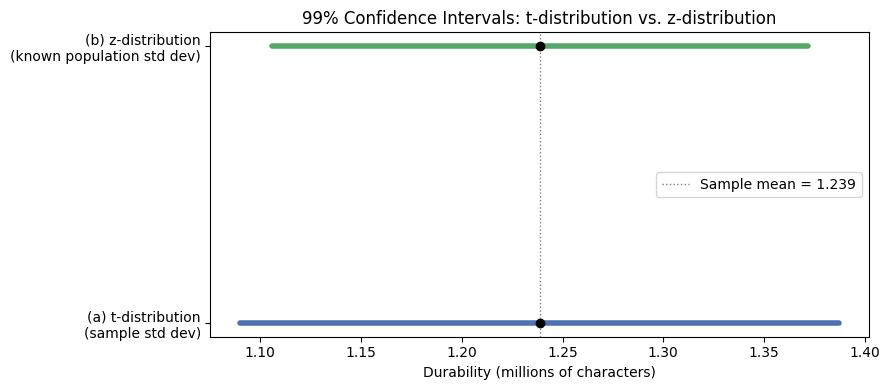

In [14]:
# Compare both intervals visually
fig, ax = plt.subplots(figsize=(9, 4))

intervals = [
    ("(a) t-distribution\n(sample std dev)", ci_lower_t, ci_upper_t, "#4C72B0"),
    ("(b) z-distribution\n(known population std dev)", ci_lower_z, ci_upper_z, "#55A868"),
]

for i, (label, lo, hi, color) in enumerate(intervals):
    ax.plot([lo, hi], [i, i], color=color, linewidth=4, solid_capstyle="round")
    ax.plot(sample_mean, i, "o", color="black", zorder=5)

ax.set_yticks(range(len(intervals)))
ax.set_yticklabels([lbl for lbl, *_ in intervals])
ax.axvline(sample_mean, color="gray", linestyle=":", linewidth=1, label=f"Sample mean = {sample_mean:.3f}")
ax.set_xlabel("Durability (millions of characters)")
ax.set_title("99% Confidence Intervals: t-distribution vs. z-distribution")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Width of interval (a) [t-distribution]: {ci_upper_t - ci_lower_t:.4f}")
print(f"Width of interval (b) [z-distribution]: {ci_upper_z - ci_lower_z:.4f}")

**Why is interval (b) narrower?** The t-distribution's critical value (2.977) is larger than the z-distribution's (2.576) — the t-distribution has heavier tails to compensate for the *extra* uncertainty of estimating $\sigma$ from a small sample. In part (b), since $\sigma$ is already known exactly (no estimation uncertainty about it), we don't need that extra cushion, so the interval is narrower. This illustrates a general principle: **not knowing the population standard deviation costs you precision** in your confidence interval, especially with small samples.

## Conclusion

- **Part (a):** using the sample standard deviation and the t-distribution (appropriate since the population standard deviation is unknown and $n=15$ is small), the 99% confidence interval for mean print-head durability is **(1.090, 1.387) million characters**.
- **Part (b):** using a known population standard deviation of 0.2 million characters and the z-distribution, the 99% confidence interval is **(1.106, 1.372) million characters** — narrower, since there's no added uncertainty from estimating $\sigma$.
- Both intervals are centered on the same sample mean (≈1.239 million characters) and overlap substantially, but the t-based interval is appropriately wider to reflect the additional uncertainty of not knowing the true population standard deviation.